### Annotate UHVDB using PHIST

In [1]:
### Load packages
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [ ]:
### identify human associated genomes in mOTUs-db

# genome2sample= pl.read_csv('Supplementary_Table_1.tsv.gz', separator='\t', comment_prefix="!")
# sample2environment = pl.read_csv('Supplementary_Table_4.tsv.gz', separator='\t', comment_prefix="!")

# human_samples = set(
#     sample2environment
#         .filter(pl.col('ENVIRONMENT').str.contains('human'))
#         ['#SAMPLE']
# )

# human_genomes = (
#     genome2sample
#         .filter(pl.col('METAGENOMIC_SAMPLE').is_in(human_samples))
#         .with_columns([
#             ("https://sunagawalab.ethz.ch/share/MOTUS/database/4.0/data/genomes/" +
#                 pl.col('STUDY') + "/" +
#                 pl.col('METAGENOMIC_SAMPLE') + "/" +
#                 pl.col("#GENOME") + "/" +
#                 pl.col("#GENOME") + ".fa.gz").alias('GENOME_URL')
#         ])
#         [['GENOME_URL']]
#         .write_csv('human_associated_mOTUs_genomes_urls.txt', include_header=False)
# )

In [ ]:
%%bash
### run nf-phist on UHVDB r2025_10 species reps vs human associated motus genomes
# git clone https://github.com/CarsonJM/nf-phist.git
# cd nf-phist

# # run nf-phist
# nextflow run . \
#     -c /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/assets/configs/conf/uw_hyak.config \
#     --host_file /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/human_associated_mOTUs_genomes_urls.txt \
#     --virus_fasta /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna.gz \
#     --chunk_size 10000 \
#     --hyak_queue 'ckpt' \
#     --hyak_partition 'stf' \
#     --output motus_human_v_uhvdb_r2025_10_votu_reps.csv

# kmer-db distance \
#     min \
#     /gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhvdb_r2025_10_votu_reps.csv \
#     /gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhvdb_r2025_10_votu_reps.min.csv

In [ ]:
%%bash
### run nf-phist on UHGV genomes (for benchmarking)
# nextflow run . \
#     -c /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/assets/configs/conf/uw_hyak.config \
#     --host_file /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/human_associated_mOTUs_genomes_urls.txt \
#     --virus_fasta /gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/votus_hq_plus.fna.gz \
#     --chunk_size 10000 \
#     --hyak_queue 'ckpt' \
#     --hyak_partition 'stf' \
#     --output motus_human_v_uhgv_hq_plus_votu_reps.csv

# # convert to percent of virus kmers hit
# kmer-db distance \
#     min \
#     /gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhgv_hq_plus_votu_reps.csv \
#     /gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhgv_hq_plus_votu_reps.min.csv

### Benchmark using UHGV

In [ ]:
# ### parse UHGV nf-phist outputs

# uhgv_dict = {}

# line_num = 0
# with open('/gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhgv_hq_plus_votu_reps.min.csv', 'r') as f_in:
#     for line in f_in:
#         if line.startswith('kmer-length'):
#             split = line.strip().split(',')[1:]
#             for index, virus in enumerate(split):
#                 uhgv_dict[index] = {
#                     'votu_id': virus,
#                     'motus_1_hits': [],
#                     'motus_5_hits': [],
#                     'motus_10_hits': [],
#                     'motus_20_hits': [],
#                     'motus_50_hits': []
#                 }
#         elif line.startswith('query-samples'):
#             continue
#         else:
#             split = line.strip().split(',')
#             motu_id = split[0]
#             for hit in split[1:-1]:
#                 # print(hit.split(':'))
#                 index, perc_kmers = hit.split(':')
#                 if float(perc_kmers) > 0.01:
#                     uhgv_dict[int(index)-1]['motus_1_hits'].append(motu_id)
#                 if float(perc_kmers) > 0.05:
#                     uhgv_dict[int(index)-1]['motus_5_hits'].append(motu_id)
#                 if float(perc_kmers) > 0.1:
#                     uhgv_dict[int(index)-1]['motus_10_hits'].append(motu_id)
#                 if float(perc_kmers) > 0.2:
#                     uhgv_dict[int(index)-1]['motus_20_hits'].append(motu_id)
#                 if float(perc_kmers) > 0.5:
#                     uhgv_dict[int(index)-1]['motus_50_hits'].append(motu_id)
#                 else:
#                     continue
#         line_num += 1
#         if line_num % 10000 == 0:
#             print(f'Processed {line_num} lines')

In [ ]:
### Create df of UHGV phist results
# # Convert dict of dicts to list of dicts
# rows = list(uhgv_dict.values())

# # Create DataFrame
# uhgv_phist = pl.DataFrame(rows)
# print("Total UHGV HQ vOTUs:",uhgv_phist['votu_id'].n_unique())

# # write to parquet so above code doesn't need to be rerun
# uhgv_phist.write_parquet('uhgv_phist_motus_hits.parquet')

Total UHGV HQ vOTUs: 57515


In [2]:
### load motus metadata and join with UHGV phist results

# !wget https://sunagawalab.ethz.ch/share/MOTUS/database/4.0/data/mOTUs4.0_genome-metadata-20250702.alpha.tsv.gz

motus_meta = pl.read_csv('mOTUs4.0_genome-metadata-20250702.alpha.tsv.gz', separator='\t', columns=['GENOME', 'SPECIES', 'GENUS', 'FAMILY', 'ORDER', 'CLASS', 'PHYLUM'])

uhgv_phist = pl.read_parquet('uhgv_phist_motus_hits.parquet')
print("Read inputs")

uhgv_annotated_lst = []

for i in [50, 20, 10, 5, 1]:

    # create a dataframe with exploded motus hits
    uhgv_phist_explode = (
        uhgv_phist
            .select(['votu_id', f'motus_{i}_hits'])
            .filter(pl.col(f'motus_{i}_hits') != [])
            .explode(f'motus_{i}_hits')
            .with_columns([
                pl.col(f'motus_{i}_hits').str.split('.fa').list[0].alias('GENOME')
            ])
    )

    # join to get host taxonomy
    uhgv_phist_annotated = (
        uhgv_phist_explode.sort('GENOME')
            .join(motus_meta.sort('GENOME'), on='GENOME', how='left')
            .rename({
                'SPECIES':'species',
                'GENUS':'genus',
                'FAMILY':'family',
                'ORDER':'order',
                'CLASS':'class',
                'PHYLUM':'phylum'
            })
    )

    print(f"Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= {i}):", uhgv_phist_annotated['votu_id'].n_unique())

    uhgv_annotated_lst.append(uhgv_phist_annotated)


Read inputs
Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= 50): 23570
Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= 20): 40824
Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= 10): 47113
Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= 5): 50737
Number of UHGV vOTUs with mOTUs predicted hosts (% kmer >= 1): 54316


In [3]:
### analyze UHGV's original phist annotations
hq_votus = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'kmers_total_connections', 'kmers_host_agreement', 'kmers_host_lineage_gtdb_r207'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns(pl.col('kmers_total_connections').cast(pl.Float64))
        .with_columns(pl.col('kmers_host_agreement').cast(pl.Float64))
        .with_columns([
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum')
        ])
)

# count UHGV PHIST assignments at each rank
print("Total UHGV HQ vOTUs:", hq_votus['uhgv_genome'].n_unique())
print("Number of UHGV HQ vOTUs with predicted hosts from kmer method:", hq_votus.filter(pl.col('kmers_total_connections') > 0)['uhgv_genome'].n_unique())
print("Number with species-level assignments:", hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
print("Number with genus-level assignments:", hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
print("Number with family-level assignments:", hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())
print("Number with order-level assignments:", hq_votus.filter(pl.col('host_order').is_not_null())['uhgv_genome'].n_unique())
print("Number with class-level assignments:", hq_votus.filter(pl.col('host_class').is_not_null())['uhgv_genome'].n_unique())
print("Number with phylum-level assignments:", hq_votus.filter(pl.col('host_phylum').is_not_null())['uhgv_genome'].n_unique())

Total UHGV HQ vOTUs: 57514
Number of UHGV HQ vOTUs with predicted hosts from kmer method: 34222
Number with species-level assignments: 22872
Number with genus-level assignments: 27402
Number with family-level assignments: 30662
Number with order-level assignments: 31344
Number with class-level assignments: 32156
Number with phylum-level assignments: 34222


In [ ]:
### Compare agreement between original UHGV phist annotations and new annotations at different %kmer cutoffs
recalls = []
precisions = []
f1s = []
num_ks = []
percents = []
props = []
ranks = []

for i in range(len(uhgv_annotated_lst)):
    uhgv_phist_annotated = uhgv_annotated_lst[i]
    for rank in ['species', 'genus', 'family']:#, 'phylum', 'order', 'class', 'phylum']:
        uhgv_new = (
            uhgv_phist_annotated
                # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
                # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
                # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
                # .with_columns(pl.col('phylum').str.split('_').list[0])
                # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
                # .with_columns(pl.col('class').str.split('_').list[0])
                .group_by(['votu_id', rank])
                .agg([
                    pl.len().alias(f'{rank}_count')
                ])
                .sort(f'{rank}_count', descending=True)
                .group_by('votu_id')
                .agg([
                    pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
                    pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
                    pl.col(rank).first().alias(f'consensus_{rank}')
                ])
                .with_columns([
                    (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
                ])
                .filter(pl.col(f'{rank}_agreement') >= 0.7)
                .filter(~pl.col(f'consensus_{rank}').str.contains('Unknown'))
        )
        for num_k in [1]:
            # identify UHVDB agreement with UHGV phist assignments
            uhgv_uhvdb_join = (
                hq_votus
                    .filter(pl.col(f'host_{rank}').is_not_null())
                    # .with_columns(pl.col('host_phylum').str.split('_').list[0])
                    .join(uhgv_new, left_on='uhgv_genome', right_on='votu_id', how='left')
                    .sort(pl.col('kmers_total_connections'))
            )

            tp = uhgv_uhvdb_join.filter(pl.col(f'host_{rank}') == pl.col(f'consensus_{rank}')).filter(pl.col(f'{rank}_total') >= num_k).height
            fp = uhgv_uhvdb_join.filter((pl.col(f'host_{rank}') != pl.col(f'consensus_{rank}')) & (~pl.col(f'consensus_{rank}').is_null())).filter(pl.col(f'{rank}_total') >= num_k).height
            fn = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}').is_null()).height

            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            if i == 0:
                percent = 50
            if i == 1:
                percent = 20
            if i == 2:
                percent = 10
            if i == 3:
                percent = 5
            if i == 4:
                percent = 1

            recalls.append(recall)
            precisions.append(precision)
            f1s.append(f1)
            num_ks.append(num_k)
            percents.append(percent)
            props.append(uhgv_new.height / hq_votus['uhgv_genome'].n_unique())
            ranks.append(rank)

NameError: name 'uhgv_annotated_lst' is not defined

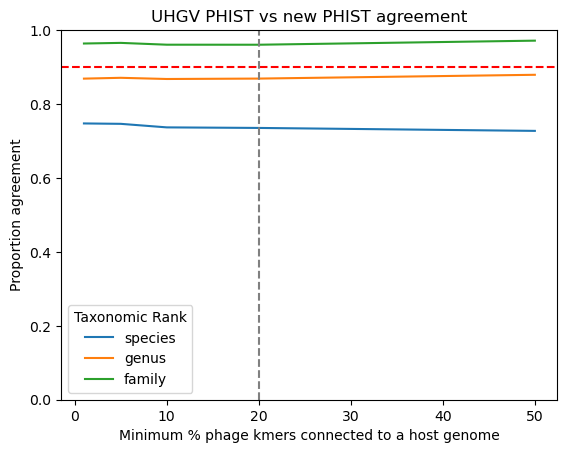

In [34]:
### plot UHGV original vs new phist agreement (% kmer cutoffs)
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_kmers': num_ks,
    'percents': percents,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn boxplot
sns.lineplot(data=precision_df, x='percents', y='precision', hue='rank')
plt.title('UHGV PHIST vs new PHIST agreement')
plt.xlabel('Minimum % phage kmers connected to a host genome')
plt.ylabel('Proportion agreement')
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=20, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

In [43]:
precision_df.filter(pl.col('percents') == 20)

rank,num_kmers,percents,recall,precision,f1_score,proportion_assigned
str,i64,i64,f64,f64,f64,f64
"""species""",1,20,0.694208,0.735355,0.714189,0.44876
"""genus""",1,20,0.862941,0.86889,0.865905,0.580137
"""family""",1,20,0.890662,0.960478,0.924254,0.61818


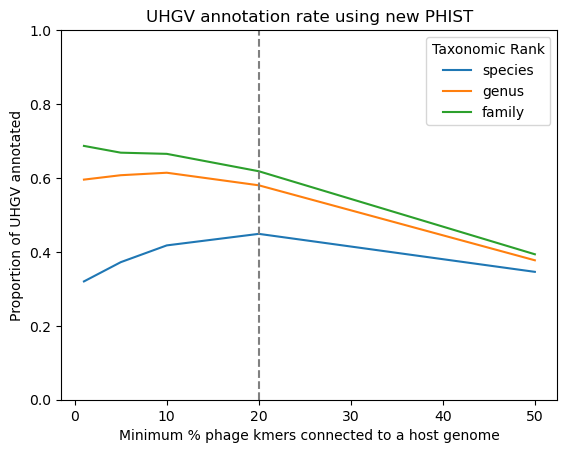

In [35]:
### plot UHGV original vs new phist agreement (% kmer cutoffs)
sns.lineplot(data=precision_df, x='percents', y='proportion_assigned', hue='rank')
plt.title('UHGV annotation rate using new PHIST')
plt.xlabel('Minimum % phage kmers connected to a host genome')
plt.ylabel('Proportion of UHGV annotated')
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axvline(x=20, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

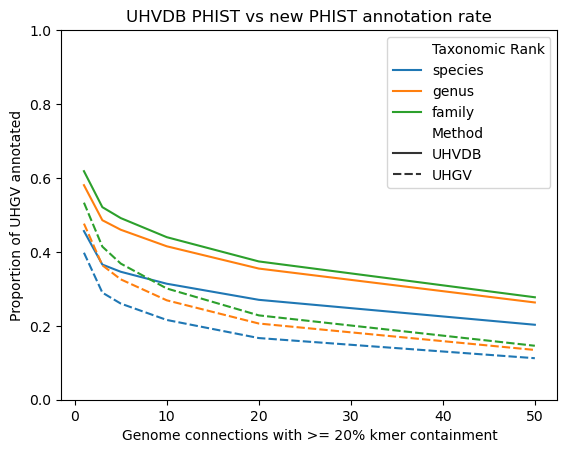

In [37]:
### Identify prop of UHGV annotated with increasing genome hit counts using old v new phist 
props = []
methods = []
num_ks = []
ranks = []

for rank in ['species', 'genus', 'family']:
    for genome_hits in [1, 3, 5, 10, 20, 50]:
        uhgv_new = (
            uhgv_annotated_lst[1]
                .group_by(['votu_id', rank])
                .agg([
                    pl.len().alias(f'{rank}_count')
                ])
                .sort(f'{rank}_count', descending=True)
                .group_by('votu_id')
                .agg([
                    pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
                    pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
                    pl.col(rank).first().alias(f'consensus_{rank}')
                ])
                .with_columns([
                    (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
                ])
                .filter(pl.col(f'{rank}_agreement') >= 0.7)
                .filter(pl.col(f'{rank}_total') >= genome_hits)
        )
        props.append(uhgv_new.height / hq_votus['uhgv_genome'].n_unique())
        methods.append('UHVDB')
        num_ks.append(genome_hits)
        ranks.append(rank)

        uhgv_old = (
            hq_votus
                .filter(pl.col(f'host_{rank}').is_not_null())
                .filter(pl.col('kmers_total_connections') >= genome_hits)
                .unique('uhgv_genome')
        )

        props.append(uhgv_old.height / hq_votus['uhgv_genome'].n_unique())
        methods.append('UHGV')
        num_ks.append(genome_hits)
        ranks.append(rank)

# create a dataframe with the results
annotation_rate_df = pl.DataFrame({
    'Taxonomic Rank': ranks,
    'num_kmers': num_ks,
    'props': props,
    'Method': methods
})

# plot results as a seaborn boxplot
sns.lineplot(data=annotation_rate_df, x='num_kmers', y='props', hue='Taxonomic Rank', style='Method')
plt.title('UHVDB PHIST vs new PHIST annotation rate')
plt.xlabel('Genome connections with >= 20% kmer containment')
plt.ylabel('Proportion of UHGV annotated')
# horizontal line at y=0.9
plt.ylim(0,1)
plt.show()

### Note: 62.6% of UHGV HQ species reps were classified as temperate (~60% have phist connections)

In [ ]:
# ### parse nf-phist outputs for UHVDB r2025_10
# uhvdb_dict = {}
# line_num = 0
# with open('/gscratch/stf/carsonjm/nf-phist-uhvdb/nf-phist/motus_human_v_uhvdb_r2025_10_votu_reps.min.csv', 'r') as f_in:
#     for line in f_in:
#         if line.startswith('kmer-length'):
#             split = line.strip().split(',')[2:]
#             for index, virus in enumerate(split):
#                 uhvdb_dict[index] = {
#                     'votu_id': virus,
#                     'motus_hits': []
#                 }
#         elif line.startswith('query-samples'):
#             continue
#         else:
#             split = line.strip().split(',')
#             motu_id = split[0]
#             for hit in split[2:-1]:
#                 # print(hit.split(':'))
#                 index, perc_kmers = hit.split(':')
#                 if float(perc_kmers) >= 0.2:
#                     uhvdb_dict[int(index)-1]['motus_hits'].append(motu_id)
#                 else:
#                     continue
#         line_num += 1
#         if line_num % 10000 == 0:
#             print(f'Processed {line_num} lines')

# # Convert dict of dicts to list of dicts
# rows = list(uhvdb_dict.values())

# # Create DataFrame
# uhvdb_phist = pl.DataFrame(rows)

# # create a dataframe with exploded motus hits
# uhvdb_phist_explode = (
#     uhvdb_phist
#         .filter(pl.col('motus_hits') != [])
#         .explode('motus_hits')
#         .with_columns([
#             pl.col('motus_hits').str.split('.fa').list[0].alias('GENOME')
#         ])
# )

# # join to get host taxonomy
# uhvdb_phist_annotated = (
#     uhvdb_phist_explode
#         .join(motus_meta, on='GENOME', how='left')
#         .rename({
#             'SPECIES':'species',
#             'GENUS':'genus',
#             'FAMILY':'family',
#             'ORDER':'order',
#             'CLASS':'class',
#             'PHYLUM':'phylum'
#         })
# )

# # write to csv
# uhvdb_phist_annotated.write_csv('uhvdb_r2025_10_motus_phist_annotations_perc_k20.csv')

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

In [2]:
### analyze UHVDB r2025_10 proportion annotated at different genome hit counts
uhvdb_phist_annotated = pl.read_csv('uhvdb_r2025_10_motus_phist_annotations_perc_k20.csv')

props = []
methods = []
genome_hit_count = []
ranks = []

for rank in ['species', 'genus', 'family']:
    for genome_hits in [1, 3, 5, 10, 20, 50]:
        uhvdb_consensus = (
            uhvdb_phist_annotated
                .group_by(['votu_id', rank])
                .agg([
                    pl.len().alias(f'{rank}_count')
                ])
                .sort(f'{rank}_count', descending=True)
                .group_by('votu_id')
                .agg([
                    pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
                    pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
                    pl.col(rank).first().alias(f'consensus_{rank}')
                ])
                .with_columns([
                    (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
                ])
                .filter(pl.col(f'{rank}_agreement') >= 0.7)
                .filter(pl.col(f'{rank}_total') >= genome_hits)
        )
        props.append(uhvdb_consensus.height / uhvdb_phist_annotated['votu_id'].n_unique())
        methods.append('UHVDB')
        genome_hit_count.append(genome_hits)
        ranks.append(rank)

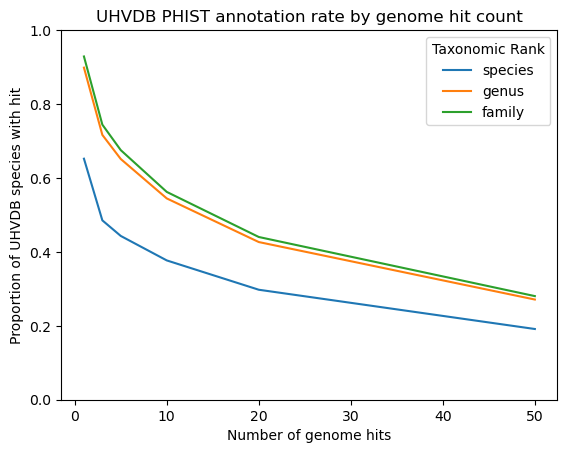

In [27]:
# create a dataframe with the results
annotation_rate_df = pl.DataFrame({
    'Taxonomic Rank': ranks,
    'genome_hit_count': genome_hit_count,
    'props': props,
})

# plot results as a seaborn boxplot
sns.lineplot(data=annotation_rate_df, x='genome_hit_count', y='props', hue='Taxonomic Rank')
plt.title('UHVDB PHIST annotation rate by genome hit count')
plt.xlabel('Number of genome hits')
plt.ylabel('Proportion of UHVDB species with hit')
# horizontal line at y=0.9
plt.ylim(0,1)
plt.show()

In [3]:
### Create final df for UHVDB PHIST host prediction
uhvdb_info = (
    pl.read_csv(
        '../uhvdb_final_files/r2025_10/uhvdb_clustering_thru_votus.tsv',
        separator='\t', columns=['seq_name', 'votu_rep']
    )
)

# identify species reps
species_reps = set(
    uhvdb_info['votu_rep']
)

uhvdb_phisttaxa = uhvdb_info.unique('votu_rep')[['votu_rep']]
uhvdb_phist_annotated = pl.read_csv('uhvdb_r2025_10_motus_phist_annotations_perc_k20.csv')

for rank in ['species', 'genus', 'family']:
    uhvdb_phisttaxa = uhvdb_phisttaxa.join(
        uhvdb_phist_annotated
            .group_by(['votu_id', rank])
            .agg([
                pl.len().alias(f'{rank}_count')
            ])
            .filter(
                (pl.col('votu_id').is_in(species_reps))
            )
            .sort(f'{rank}_count', descending=True)
            .group_by('votu_id')
            .agg([
                pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
                pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
                pl.col(rank).first().alias(f'consensus_{rank}')
            ])
            .with_columns([
                (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
            ])
            .filter(pl.col(f'{rank}_agreement') >= 0.7),
        left_on='votu_rep', right_on='votu_id', how='left'
    )

In [4]:
uhvdb_phisttaxa.write_csv('uhvdb_r2025_10_species_phist_host_predictions.tsv', separator='\t')